In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

In [4]:
df = pd.read_csv("Player.csv")

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,id,player_api_id,player_name,player_fifa_api_id,birthday,height,weight
0,1,505942,Aaron Appindangoye,218353,1992-02-29 00:00:00,182.88,187
1,2,155782,Aaron Cresswell,189615,1989-12-15 00:00:00,170.18,146
2,3,162549,Aaron Doran,186170,1991-05-13 00:00:00,170.18,163
3,4,30572,Aaron Galindo,140161,1982-05-08 00:00:00,182.88,198
4,5,23780,Aaron Hughes,17725,1979-11-08 00:00:00,182.88,154


In [6]:
print("Missing Values in Each Column")
print(df.isnull().sum())

Missing Values in Each Column
id                    0
player_api_id         0
player_name           0
player_fifa_api_id    0
birthday              0
height                0
weight                0
dtype: int64


In [14]:
columns = ['height', 'weight']

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

height: 156 outliers
weight: 61 outliers


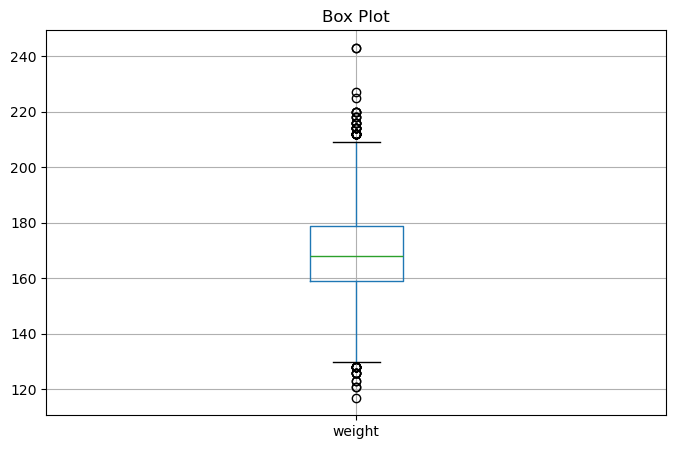

In [20]:
if len(columns) > 0:
    plt.figure(figsize=(8,5))
    df.boxplot(column=columns[1])
    plt.title("Box Plot")
    plt.show()

In [26]:
scaler = MinMaxScaler()

df[columns] = scaler.fit_transform(df[columns])

print("Normalization Completed")
df[columns].head()

Normalization Completed


,height,weight
0,0.50,0.555556
1,0.25,0.230159
2,0.25,0.365079
3,0.50,0.642857
4,0.50,0.293651


In [36]:
from sklearn.preprocessing import LabelEncoder

df["Category"] = ["A" if h > 180 else "B" for h in df["height"]]

encoder = LabelEncoder()
df["Category_Encoded"] = encoder.fit_transform(df["Category"])

df.head()

,id,player_api_id,player_name,player_fifa_api_id,birthday,height,weight,Category,Category_Encoded,Player_Name_Encoded
0,1,505942,0,218353,4504,0.50,0.555556,B,0,0
1,2,155782,1,189615,3833,0.25,0.230159,B,0,1
2,3,162549,2,186170,4267,0.25,0.365079,B,0,2
3,4,30572,3,140161,1566,0.50,0.642857,B,0,3
4,5,23780,4,17725,921,0.50,0.293651,B,0,4


In [38]:
encoded = pd.get_dummies(df["Category"])
print(encoded.head())

      B
0  True
1  True
2  True
3  True
4  True


In [42]:
print(df.dtypes)

id                       int64
player_api_id            int64
player_name              int32
player_fifa_api_id       int64
birthday                 int32
height                 float64
weight                 float64
Category                object
Category_Encoded         int32
Player_Name_Encoded      int64
dtype: object


In [44]:
df.head()

,id,player_api_id,player_name,player_fifa_api_id,birthday,height,weight,Category,Category_Encoded,Player_Name_Encoded
0,1,505942,0,218353,4504,0.50,0.555556,B,0,0
1,2,155782,1,189615,3833,0.25,0.230159,B,0,1
2,3,162549,2,186170,4267,0.25,0.365079,B,0,2
3,4,30572,3,140161,1566,0.50,0.642857,B,0,3
4,5,23780,4,17725,921,0.50,0.293651,B,0,4
